In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

REFORM_COLOR = '#12239E'
ACCENT_COLOR = '#E8102A'

print("Imports OK")

Imports OK


In [20]:
df = pd.read_csv('../../data/processed/model_data.csv')

print(f"Shape: {df.shape[0]} constituencies × {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")
print(f"Missing values: {df.isnull().sum().sum()}")
df.head()

Shape: 630 constituencies × 11 columns
Columns: ['constituency', 'reform_vote_share', 'leave_vote_share', 'degree_pct', 'median_age', 'median_weekly_wage', 'claimant_rate', 'foreign_born_pct', 'population_density', 'ethnic_minority_pct', 'deprivation_score']
Missing values: 0


,constituency,reform_vote_share,leave_vote_share,degree_pct,median_age,median_weekly_wage,claimant_rate,foreign_born_pct,population_density,ethnic_minority_pct,deprivation_score
0,Aberafan Maesteg,20.931338,61.444880,23.706702,42.0,672.9,3.9,3.381177,372.567563,3.104561,32.413951
1,Aberdeen North,8.982064,43.946185,31.865207,39.0,740.3,4.0,19.174089,1095.146636,12.390796,17.028158
2,Aberdeen South,6.902578,34.231103,44.173184,37.0,801.8,2.9,22.960592,1160.091129,14.483290,12.845410
3,Aberdeenshire North and Moray East,14.564785,54.447209,20.875504,46.0,687.4,2.7,7.232546,72.279646,1.852896,17.124977
4,Airdrie and Shotts,8.102875,39.387435,21.261985,42.0,761.5,3.3,4.513913,392.765624,3.379146,27.067667


In [21]:
feature_labels = {
    'reform_vote_share':   'Reform UK vote share (%)',
    'leave_vote_share':    'Brexit Leave vote (%)',
    'degree_pct':          'Degree holders (%)',
    'median_age':          'Median age (years)',
    'median_weekly_wage':  'Median weekly wage (£)',
    'claimant_rate':       'Claimant rate (%)',
    'foreign_born_pct':    'Foreign-born (%)',
    'population_density':  'Population density (per km²)',
    'ethnic_minority_pct': 'Ethnic minority (%)',
    'deprivation_score':   'Deprivation score',
}

desc = df.describe().T.drop('count', axis=1).round(2)
desc.index = [feature_labels.get(i, i) for i in desc.index]
desc

,mean,std,min,25%,50%,75%,max
Reform UK vote share (%),14.84,7.16,0.00,9.43,15.21,19.67,46.18
Brexit Leave vote (%),51.88,11.41,15.93,45.38,53.54,59.87,76.19
Degree holders (%),33.45,8.97,18.08,26.96,31.62,37.57,65.22
Median age (years),41.16,5.56,24.00,37.00,41.00,45.00,56.00
Median weekly wage (£),774.16,99.17,603.40,700.68,754.85,831.90,1167.30
Claimant rate (%),3.83,1.84,1.40,2.50,3.30,4.60,15.60
Foreign-born (%),15.23,12.31,2.61,6.26,10.77,19.47,62.22
Population density (per km²),2188.47,2861.48,7.95,309.91,1022.30,3207.58,19757.69
Ethnic minority (%),16.02,16.86,1.61,3.96,8.83,21.77,79.89
Deprivation score,21.38,8.86,5.73,14.56,19.92,27.13,50.48


In [22]:
cols_display = ['constituency', 'reform_vote_share', 'leave_vote_share',
                'degree_pct', 'median_weekly_wage']

print("Top 10 — highest Reform UK vote share:")
display(df.nlargest(10, 'reform_vote_share')[cols_display].round(2).reset_index(drop=True))

print("\nBottom 10 — lowest Reform UK vote share:")
display(df.nsmallest(10, 'reform_vote_share')[cols_display].round(2).reset_index(drop=True))

Top 10 — highest Reform UK vote share:


,constituency,reform_vote_share,leave_vote_share,degree_pct,median_weekly_wage
0,Clacton,46.18,71.81,18.15,683.7
1,Ashfield,42.78,70.81,20.82,669.2
2,Boston and Skegness,38.36,76.19,18.08,606.3
3,Great Yarmouth,35.30,71.50,18.24,699.2
4,Barnsley South,33.21,71.34,20.19,700.5
5,Makerfield,31.80,65.86,24.68,762.2
6,South Basildon and East Thurrock,30.79,74.05,22.27,865.0
7,Kingston upon Hull East,30.61,70.95,18.61,624.6
8,Rotherham,30.27,67.91,21.51,692.1
9,Castle Point,30.11,72.79,18.50,808.2



Bottom 10 — lowest Reform UK vote share:


,constituency,reform_vote_share,leave_vote_share,degree_pct,median_weekly_wage
0,Blaenau Gwent and Rhymney,0.0,63.51,20.85,713.1
1,Brighton Kemptown and Peacehaven,0.0,42.33,34.60,788.3
2,Bristol East,0.0,46.08,37.38,775.6
3,Cambridge,0.0,25.28,55.71,844.3
4,Cheltenham,0.0,42.51,44.77,829.4
5,Chorley,0.0,57.14,33.59,761.5
6,Doncaster North,0.0,71.50,21.03,710.4
7,Earley and Woodley,0.0,48.12,40.53,932.6
8,East Grinstead and Uckfield,0.0,48.99,36.32,832.2
9,Epping Forest,0.0,61.29,34.32,863.0


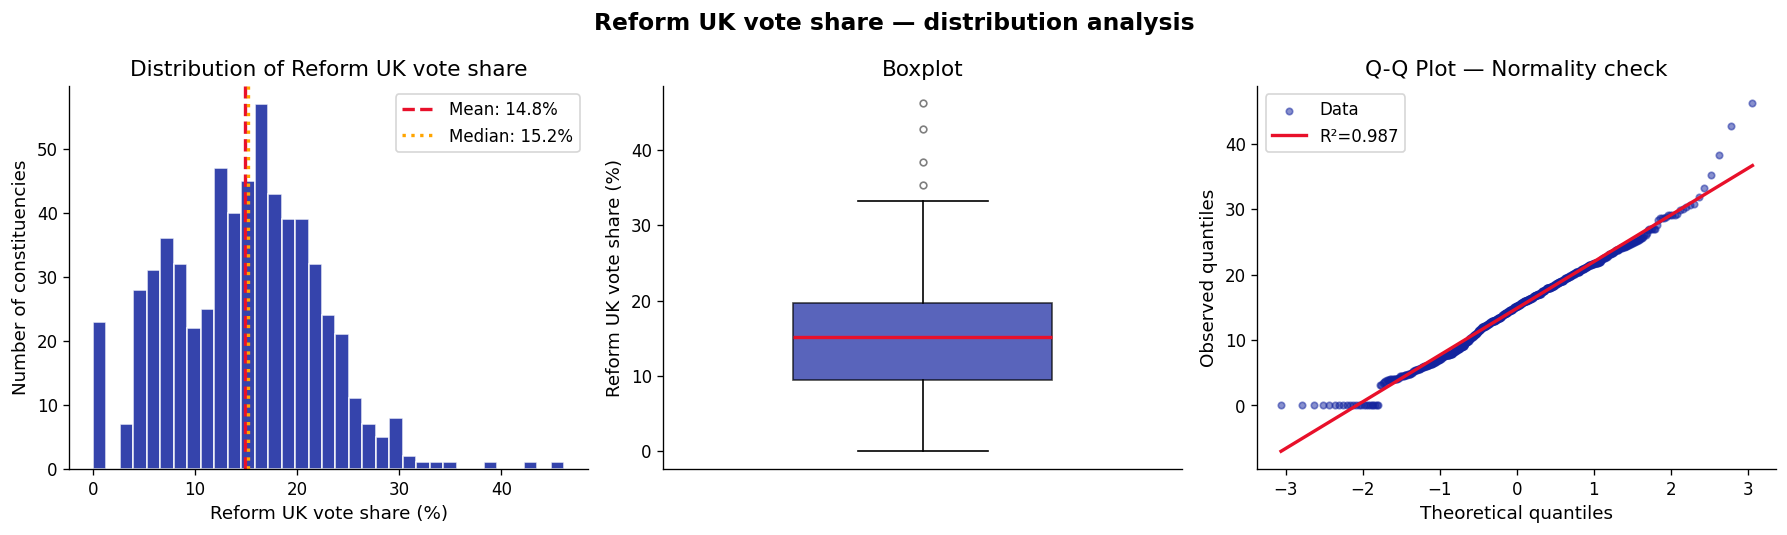

Shapiro-Wilk: W=0.9873, p=0.0000
Skewness: 0.202
Kurtosis: 0.400


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

ax = axes[0]
ax.hist(df['reform_vote_share'], bins=35, color=REFORM_COLOR, alpha=0.85, edgecolor='white')
ax.axvline(df['reform_vote_share'].mean(), color=ACCENT_COLOR, lw=2, linestyle='--',
           label=f"Mean: {df['reform_vote_share'].mean():.1f}%")
ax.axvline(df['reform_vote_share'].median(), color='orange', lw=2, linestyle=':',
           label=f"Median: {df['reform_vote_share'].median():.1f}%")
ax.set_xlabel("Reform UK vote share (%)")
ax.set_ylabel("Number of constituencies")
ax.set_title("Distribution of Reform UK vote share")
ax.legend()

ax = axes[1]
ax.boxplot(df['reform_vote_share'], patch_artist=True, widths=0.5,
           boxprops=dict(facecolor=REFORM_COLOR, alpha=0.7),
           medianprops=dict(color=ACCENT_COLOR, lw=2),
           flierprops=dict(marker='o', markersize=4, alpha=0.5))
ax.set_title("Boxplot")
ax.set_ylabel("Reform UK vote share (%)")
ax.set_xticks([])

ax = axes[2]
(osm, osr), (slope, intercept, r) = stats.probplot(df['reform_vote_share'], dist="norm")
ax.scatter(osm, osr, color=REFORM_COLOR, alpha=0.5, s=15, label='Data')
ax.plot(osm, slope * np.array(osm) + intercept, color=ACCENT_COLOR, lw=2, label=f'R²={r**2:.3f}')
ax.set_xlabel("Theoretical quantiles")
ax.set_ylabel("Observed quantiles")
ax.set_title("Q-Q Plot — Normality check")
ax.legend()

plt.suptitle("Reform UK vote share — distribution analysis", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../../outputs/eda_01_distribution.png', bbox_inches='tight')
plt.show()

stat, p = stats.shapiro(df['reform_vote_share'])
print(f"Shapiro-Wilk: W={stat:.4f}, p={p:.4f}")
print(f"Skewness: {df['reform_vote_share'].skew():.3f}")
print(f"Kurtosis: {df['reform_vote_share'].kurt():.3f}")

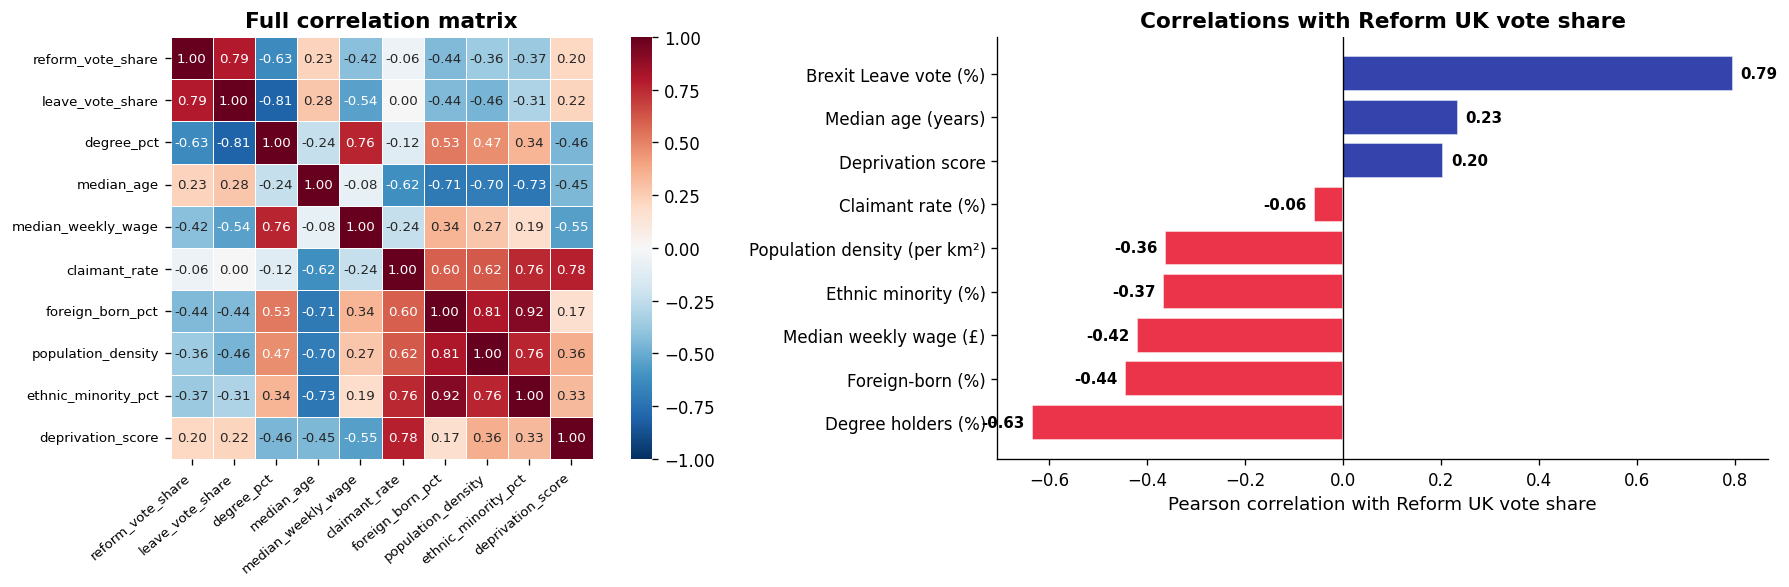

In [24]:
feature_cols = [c for c in df.columns if c != 'constituency']
corr = df[feature_cols].corr()
target_corr = corr['reform_vote_share'].drop('reform_vote_share').sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=axes[0], square=True, linewidths=0.5,
            annot_kws={'size': 8})
axes[0].set_title("Full correlation matrix", fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=40, ha='right', fontsize=8)
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0, fontsize=8)

ax = axes[1]
colors_bar = [REFORM_COLOR if v > 0 else ACCENT_COLOR for v in target_corr.values]
bars = ax.barh(range(len(target_corr)), target_corr.values,
               color=colors_bar, alpha=0.85, edgecolor='white')
ax.set_yticks(range(len(target_corr)))
ax.set_yticklabels([feature_labels.get(i, i) for i in target_corr.index])
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel("Pearson correlation with Reform UK vote share")
ax.set_title("Correlations with Reform UK vote share", fontweight='bold')
for bar, val in zip(bars, target_corr.values):
    ax.text(val + (0.015 if val >= 0 else -0.015),
            bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center',
            ha='left' if val >= 0 else 'right',
            fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('../../outputs/eda_02_correlations.png', bbox_inches='tight')
plt.show()

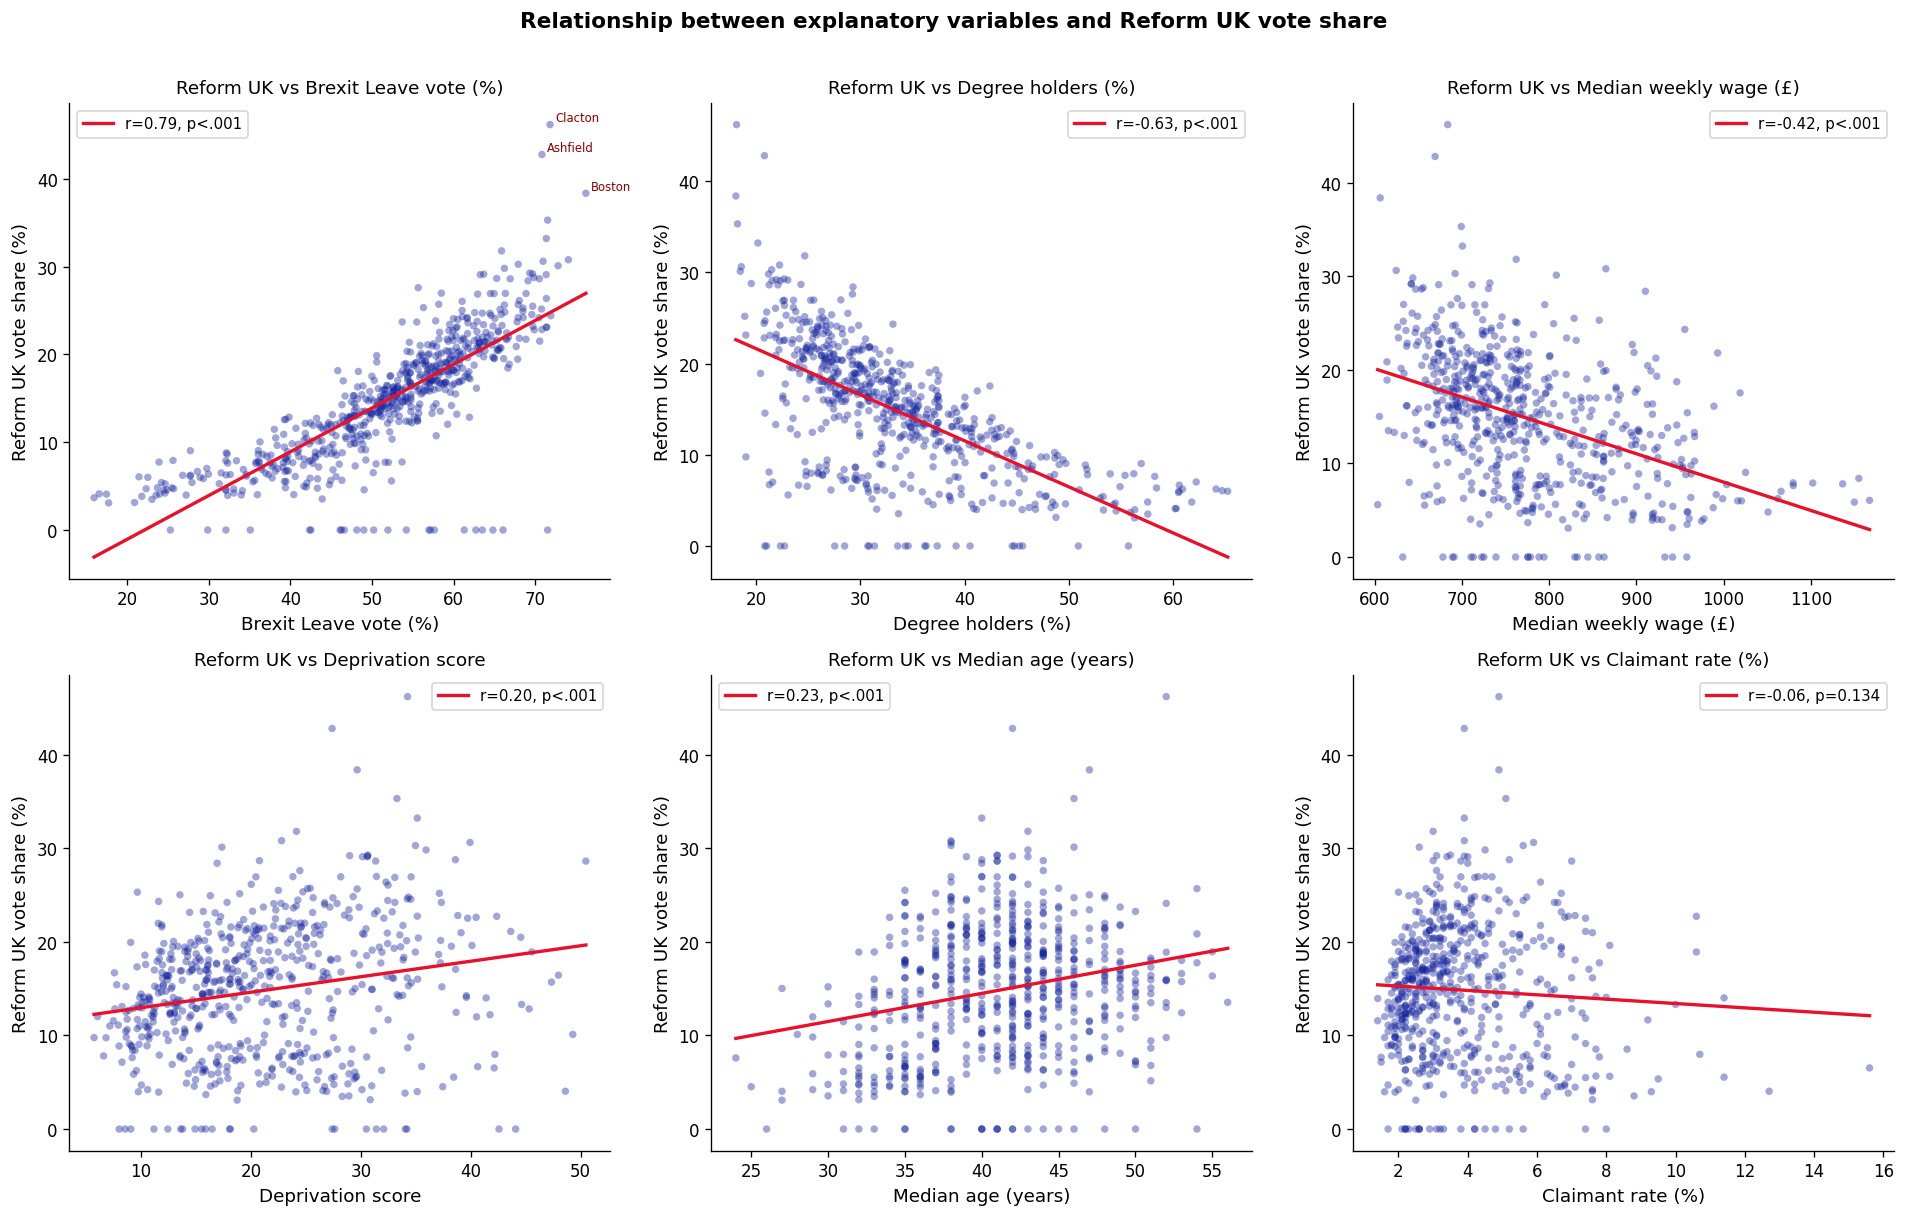

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

key_vars = [
    ('leave_vote_share',   'Brexit Leave vote (%)'),
    ('degree_pct',         'Degree holders (%)'),
    ('median_weekly_wage', 'Median weekly wage (£)'),
    ('deprivation_score',  'Deprivation score'),
    ('median_age',         'Median age (years)'),
    ('claimant_rate',      'Claimant rate (%)'),
]

for i, (col, label) in enumerate(key_vars):
    ax = axes[i]
    ax.scatter(df[col], df['reform_vote_share'],
               alpha=0.4, s=20, color=REFORM_COLOR, edgecolors='none')

    m, b, r, p, _ = stats.linregress(df[col], df['reform_vote_share'])
    x_line = np.linspace(df[col].min(), df[col].max(), 200)
    pstr = '<.001' if p < 0.001 else f'={p:.3f}'
    ax.plot(x_line, m * x_line + b, color=ACCENT_COLOR, lw=2, label=f'r={r:.2f}, p{pstr}')

    if col == 'leave_vote_share':
        for _, row in df.nlargest(3, 'reform_vote_share').iterrows():
            ax.annotate(row['constituency'].split()[0],
                        (row[col], row['reform_vote_share']),
                        fontsize=7, color='darkred',
                        xytext=(3, 2), textcoords='offset points')

    ax.set_xlabel(label)
    ax.set_ylabel("Reform UK vote share (%)")
    ax.set_title(f"Reform UK vs {label}", fontsize=11)
    ax.legend(fontsize=9)

plt.suptitle("Relationship between explanatory variables and Reform UK vote share",
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../../outputs/eda_03_scatterplots.png', bbox_inches='tight')
plt.show()

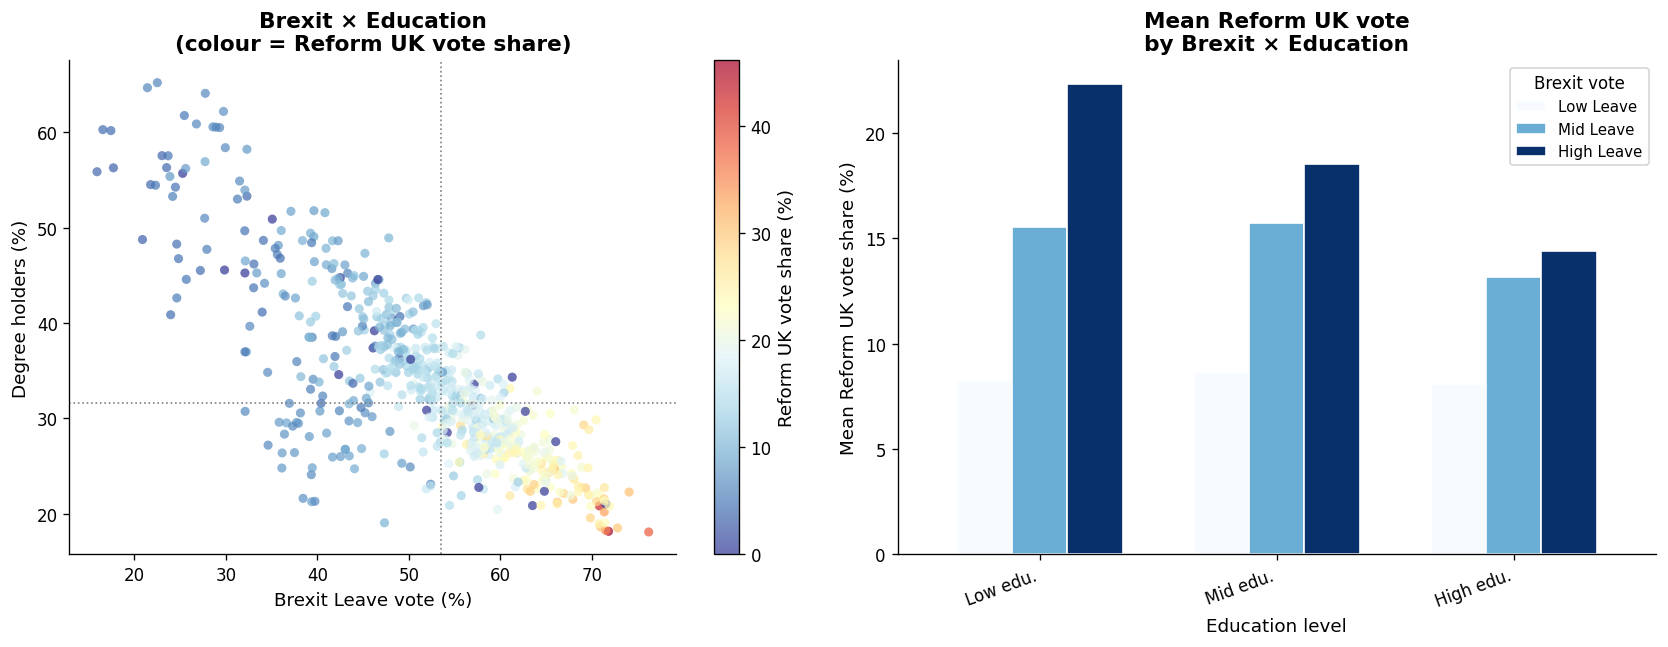

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ax = axes[0]
scatter = ax.scatter(df['leave_vote_share'], df['degree_pct'],
                     c=df['reform_vote_share'], cmap='RdYlBu_r',
                     alpha=0.7, s=30, edgecolors='none')
plt.colorbar(scatter, ax=ax, label='Reform UK vote share (%)')
ax.axhline(df['degree_pct'].median(), color='gray', lw=1, linestyle=':')
ax.axvline(df['leave_vote_share'].median(), color='gray', lw=1, linestyle=':')
ax.set_xlabel("Brexit Leave vote (%)")
ax.set_ylabel("Degree holders (%)")
ax.set_title("Brexit × Education\n(colour = Reform UK vote share)", fontweight='bold')

df['brexit_tertile'] = pd.qcut(df['leave_vote_share'], 3,
                                labels=['Low Leave', 'Mid Leave', 'High Leave'])
df['edu_tertile'] = pd.qcut(df['degree_pct'], 3,
                             labels=['Low edu.', 'Mid edu.', 'High edu.'])

pivot = df.groupby(['edu_tertile', 'brexit_tertile'], observed=True)['reform_vote_share'].mean().unstack()

ax = axes[1]
pivot.plot(kind='bar', ax=ax, colormap='Blues', edgecolor='white', width=0.7)
ax.set_xlabel("Education level")
ax.set_ylabel("Mean Reform UK vote share (%)")
ax.set_title("Mean Reform UK vote\nby Brexit × Education", fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
ax.legend(title="Brexit vote", fontsize=9)

df = df.drop(columns=['brexit_tertile', 'edu_tertile'])

plt.tight_layout()
plt.savefig('../../outputs/eda_04_brexit_education.png', bbox_inches='tight')
plt.show()

## Key Takeaways from the EDA

The strongest predictor of Reform UK vote share is the 2016 Brexit Leave vote 
(r = 0.79). Constituencies that voted heavily to leave the EU in 2016 consistently 
show higher Reform support in 2024, suggesting a stable protest electorate.

Education level is the second most important variable (r = -0.63). The lower the 
share of degree-holders in a constituency, the higher the Reform vote — a pattern 
commonly associated with populist parties across Europe.

Economic variables such as median wage (r = -0.42) and foreign-born share 
(r = -0.44) show moderate negative correlations. Interestingly, the claimant rate 
(r = -0.06, p = 0.134) shows no significant relationship with Reform support, 
which challenges the narrative that Reform voters are primarily driven by direct 
economic hardship.

The